# Dax Virani | Mall Customer Segmentation
A richer clustering notebook with synthetic data generation, scaling, K-means model selection, PCA visualization, and cluster profiling.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "#0F1117",
    "axes.facecolor": "#171A27",
    "axes.labelcolor": "#E5E7EB",
    "xtick.color": "#E5E7EB",
    "ytick.color": "#E5E7EB",
    "text.color": "#E5E7EB",
    "font.family": "DejaVu Sans"
})

DATA_PATH = Path("mall_customers.csv")
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
else:
    rng = np.random.default_rng(42)
    profiles = [(80, 25, 8, 78, 10, 24, 4), (90, 85, 12, 82, 8, 32, 6), (95, 55, 10, 50, 12, 38, 8), (85, 25, 7, 22, 9, 45, 9), (100, 82, 10, 18, 8, 42, 8)]
    rows = []
    cid = 1
    for n, im, is_, sm, ss, am, as_ in profiles:
        for _ in range(n):
            rows.append({
                "CustomerID": cid,
                "Gender": rng.choice(["Male", "Female"]),
                "Age": int(np.clip(rng.normal(am, as_), 18, 70)),
                "Annual Income (k$)": int(np.clip(rng.normal(im, is_), 10, 140)),
                "Spending Score (1-100)": int(np.clip(rng.normal(sm, ss), 1, 100))
            })
            cid += 1
    df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
    df.to_csv(DATA_PATH, index=False)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,408,Female,59,91,25
1,445,Female,27,73,22
2,118,Female,20,69,70
3,31,Female,20,22,86
4,416,Male,40,84,36


## Exploration and Scaling
The clustering model uses income and spending score as the primary behavioral axes.

In [2]:
display(df.describe().round(2))
display(df.groupby("Gender").mean(numeric_only=True).round(2))

features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,450.00,450.00,450.00,450.00
mean,225.50,36.04,54.80,48.14
std,130.05,10.49,27.15,28.75
min,1.00,18.00,10.00,1.00
25%,113.25,27.00,27.00,22.00
50%,225.50,36.00,56.00,45.00
75%,337.75,43.75,81.00,75.00
max,450.00,67.00,114.00,100.00


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,,
Female,227.37,35.8,55.62,47.43
Male,223.60,36.3,53.96,48.86


array([[ 1.33476898, -0.80563925],
       [ 0.67111244, -0.91009689],
       [ 0.52363321,  0.76122541],
       [-1.20924777,  1.31833284],
       [ 1.07668033, -0.42262789]])

## Cluster Selection and Projection
Elbow, silhouette, and PCA together provide a compact and defensible view of segmentation quality.

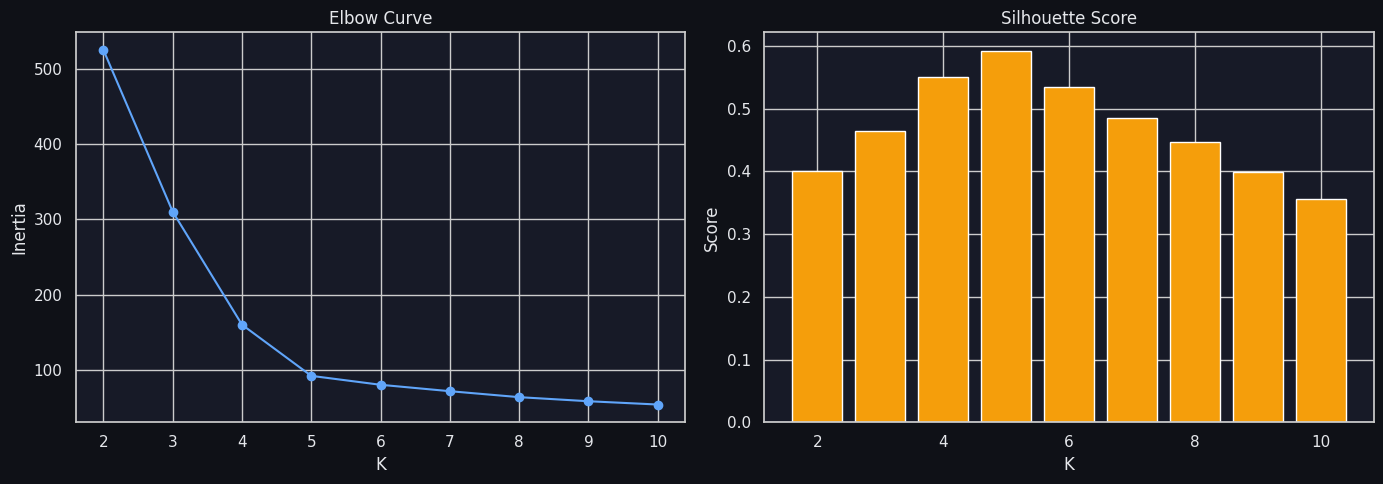

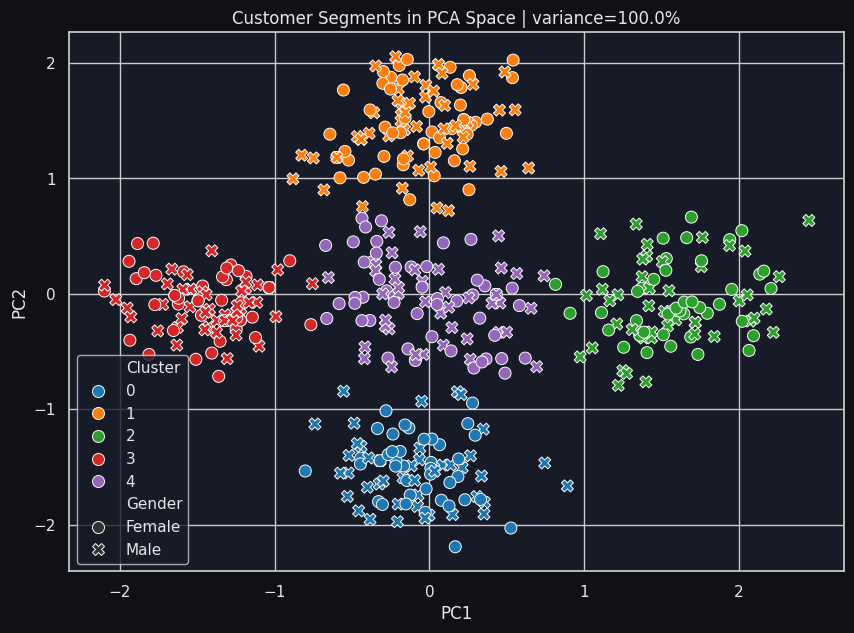

In [3]:
k_range = range(2, 11)
inertias = []
silhouettes = []
for k in k_range:
    model = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

best_k = list(k_range)[int(np.argmax(silhouettes))]
final_model = KMeans(n_clusters=best_k, n_init=20, random_state=42)
df["Cluster"] = final_model.fit_predict(X_scaled)
centers = scaler.inverse_transform(final_model.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker="o", color="#60A5FA")
axes[0].set_title("Elbow Curve")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[1].bar(list(k_range), silhouettes, color="#F59E0B")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pc, columns=["PC1", "PC2"]).join(df[["Cluster", "Gender"]])
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", style="Gender", palette="tab10", s=75, ax=ax)
ax.set_title(f"Customer Segments in PCA Space | variance={pca.explained_variance_ratio_.sum():.1%}")
plt.show()

## Cluster Profiles
These profiles help translate clusters into actionable marketing personas.

In [4]:
cluster_profile = df.groupby("Cluster")[features + ["Age"]].mean().round(2)
cluster_size = df["Cluster"].value_counts().sort_index().rename("count")
display(cluster_profile.join(cluster_size))
display(pd.DataFrame({
    "best_k": [best_k],
    "silhouette": [round(max(silhouettes), 4)],
    "pca_variance": [round(pca.explained_variance_ratio_.sum(), 4)]
}))

,Annual Income (k$),Spending Score (1-100),Age,count
Cluster,,,,
0,24.19,77.29,24.07,83
1,81.31,17.17,41.30,100
2,83.66,81.75,31.82,89
3,25.62,20.74,43.66,88
4,53.54,49.21,37.98,90


,best_k,silhouette,pca_variance
0,5,0.5923,1.0
